In [810]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [811]:
from data_utils import get_tokenizer, get_train_dataset
# from model_utils import get_model
from generate import force_args
from generate import generate_seq

import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from model_utils import SSMTransformer

In [812]:
class Args:
    def __init__(self):
        self.model = "hybrid"
        self.num_vocab = 32
        self.train_task = "decode-recall"
        self.num_numbers = 2
        self.nope = False
        self.layers = ['SSM', 'SSM', 'TF']
        self.hidden_size = 12
        self.heads = 1
        self.state_dim = 1
        self.sequence_length = 100

        self.pack_examples = False
        self.min_train_length = 97
        self.max_train_length = 98
        self.min_test_length = 97
        self.max_test_length = 98

        self.num_examples = 1000

        self.train_batch_size = 4
        self.test_batch_size = 4

        self.p = 0.2

args = Args()
force_args(args)

tokenizer = get_tokenizer(args)
train_dataset = get_train_dataset(args, tokenizer) 

In [813]:
batch = 2
seq_len = 100
size_vocab = 34

l = max(int(math.log2(seq_len)), int(math.log2(size_vocab))) + 2
d_model = 3 * l + 1 + 5 + 5 + 2 * l

# x = torch.randn(batch, seq_len, d_model)

model = SSMTransformer(
    num_vocab=size_vocab,
    d_model=d_model,
    d_state=5,
    n_heads=1,
    d_ff=-1,
    layers=['SSM', 'SSM', 'TF'],
)

# y = model(x)
# print(y.shape)  # (2, 64, 128)


In [814]:
d_model

51

In [815]:
model

SSMTransformer(
  (embedding): Embedding(34, 51)
  (layers): ModuleList(
    (0-1): 2 x SSMTransformerBlock(
      (layer): SimpleSSM(
        (Wo): Linear(in_features=51, out_features=51, bias=False)
      )
    )
    (2): SSMTransformerBlock(
      (layer): CausalSelfAttention(
        (qkv): Linear(in_features=51, out_features=153, bias=False)
        (out): Linear(in_features=51, out_features=51, bias=False)
      )
    )
  )
  (lm_head): Linear(in_features=51, out_features=34, bias=True)
)

In [816]:
emb = torch.zeros((34, d_model))
for i in range(34):
    t = i
    if tokenizer.TO_STR[i][0] == "#":
        t = int(tokenizer.TO_STR[i][1:]) #+ 1

    for j in range(l-1, 0, -1):
        # emb[i,j] = t % 2 # 0/1 binary
        emb[i,j] = 2*(t % 2) - 1 # -1/1 binary encoding
        t //= 2

    if tokenizer.TO_STR[i][0] == "#": # If the token is a number token
        emb[i,2*l:3*l] = emb[i,:l]

        emb[i,0] = 1 # Indicator for being a number token
        emb[i,2*l] = 1 # Indicator for being a number token
        if tokenizer.TO_STR[i][1] == "0":
            emb[i,3*l+1:3*l+6] = -1 # Indicators for being a number token
        else:
            emb[i,3*l+1:3*l+6] = 1 # Indicators for being a number token

emb[:,3*l] = 1 # For bias terms

model.embedding.weight.data.copy_(emb)
print()

In [817]:
pos_emb = torch.zeros_like(model.pos_emb.data)
for i in range(seq_len):
    t = i + 1
    # t = seq_len - i
    # t = seq_len - i - 1
    for j in range(-1, -l-1, -1):
        # pos_emb[0,i,j] = t % 2 # 0/1 binary
        pos_emb[0,i,j] = 2*(t % 2) - 1 # -1/1 binary encoding
        t //= 2
    pos_emb[0,i,-l] = 1.0 * i / seq_len # Bias term

model.pos_emb.data.copy_(pos_emb)
print()

In [818]:
h0 = torch.zeros_like(model.layers[0].layer.h0.data)

h0[:, 3*l+1:3*l+6] = -1 # Indicators for no numbers stored

model.layers[0].layer.h0.data.copy_(h0)
print()

In [819]:
A = torch.zeros_like(model.layers[0].layer.A.data)
d = A.shape[1]
assert d == 5
# A[3*l+1:3*l+6,1:,:-1] += 10 * torch.eye(d-1)  # M = 10
A[3*l+1:3*l+6,:-1,1:] += 1 * torch.eye(d-1)  # M = 10

model.layers[0].layer.A.data.copy_(A)
print()

In [820]:
B = torch.zeros_like(model.layers[0].layer.B.data)
# B[3*l+1:3*l+6, -1] = 1 # Identity
# B[3*l+5, :] = 1 # Identity
B[3*l, -1] = 1 # Identity
print(torch.sum(B))

model.layers[0].layer.B.data.copy_(B)
print()

tensor(1.)



In [821]:
C = torch.zeros_like(model.layers[0].layer.C.data)

model.layers[0].layer.C.data.copy_(C)

Cb = torch.zeros_like(model.layers[0].layer.Cb.data)
Cb[3*l+1:3*l+6, :] = torch.eye(5)

model.layers[0].layer.Cb.data.copy_(Cb)
print()

In [822]:
Delta = torch.zeros_like(model.layers[0].layer.Delta.data)
Delta[2*l] = 1 # Position of the number token

model.layers[0].layer.Delta.data.copy_(Delta)
print()

In [823]:
Wo = torch.zeros_like(model.layers[0].layer.Wo.weight.data)
# Wo[3*l+1:3*l+6, 3*l+6:3*l+11] = torch.eye(5)  
Wo[3*l+6:3*l+11, 3*l+1:3*l+6] = torch.eye(5)  

model.layers[0].layer.Wo.weight.data.copy_(Wo)
print()

In [824]:
A = torch.zeros_like(model.layers[1].layer.A.data)
d = A.shape[1]
assert d == 5
# A[:l,-2,-1] = 1  # M = 10
A[:l,:-1,1:] += 1 * torch.eye(d-1)  # M = 10

model.layers[1].layer.A.data.copy_(A)
print()

In [825]:
B = torch.zeros_like(model.layers[1].layer.B.data)
# B[3*l+1:3*l+6, -1] = 1 # Identity
# B[3*l+5, :] = 1 # Identity
B[3*l, -1] = 1 # Identity
print(torch.sum(B))

model.layers[1].layer.B.data.copy_(B)
print()

tensor(1.)



In [826]:
C = torch.zeros_like(model.layers[1].layer.C.data)

model.layers[1].layer.C.data.copy_(C)

Cb = torch.zeros_like(model.layers[1].layer.Cb.data)
Cb[:l, -2] = 1

model.layers[1].layer.Cb.data.copy_(Cb)
print()

In [827]:
Delta = torch.zeros_like(model.layers[1].layer.Delta.data)
Delta[3*l] = 1 # Always one

model.layers[1].layer.Delta.data.copy_(Delta)
print()

In [828]:
Wo = torch.zeros_like(model.layers[1].layer.Wo.weight.data)
# Wo[3*l+1:3*l+6, 3*l+6:3*l+11] = torch.eye(5)  
Wo[l:2*l, :l] = torch.eye(l)  

model.layers[1].layer.Wo.weight.data.copy_(Wo)
print()

In [829]:
Wq = torch.zeros((d_model, d_model))
Wk = torch.zeros((d_model, d_model))
Wv = torch.zeros((d_model, d_model))

# Wk[:5, l-5:l] = torch.eye(5)
Wk[:5, 2*l-5:2*l] = torch.eye(5)
Wk[5, -l] = 1

Wq[:5, 3*l+6:3*l+11] = 10000 * torch.eye(5)
Wq[5, 3*l] = 10000

Wv[:l, :l] = torch.eye(l)
# Wv[:l, l:2*l] = torch.eye(l)

model.layers[2].layer.qkv.weight.data.copy_(torch.concat([Wq, Wk, Wv], dim=0))
print()

In [830]:
out = torch.zeros_like(model.layers[2].layer.out.weight.data)
# Wo = torch.eye(model.layers[0].ssm.Wo.weight.data.shape[0])
# out[3*l+2:4*l+2, :l] = torch.eye(l)  
out[-2*l:-l, :l] = torch.eye(l)  

model.layers[2].layer.out.weight.data.copy_(out)
print()

In [831]:
lm_head = torch.zeros_like(model.lm_head.weight.data)
lm_head[:,-2*l:-l] = model.embedding.weight.data[:,:l]

model.lm_head.weight.data.copy_(lm_head)
print()

In [832]:
first_data = train_dataset[0]
x = first_data['input_ids']
y = first_data['output_ids']

' '.join(first_data['input'][0])

'V9 V1 V18 V28 V16 V0 V0 V17 V23 V3 #1 V10 #1 #1 V20 V30 V0 #0 V23 V9 V31 V4 V14 V21 #1 V16 V1 V13 V22 V15 #0 #0 V5 V17 V25 V7 V8 V1 V2 V30 V11 #1 V25 V13 V21 #0 V20 V6 #0 V12 V26 V27 #1 #1 V8 V6 V18 #1 #0 V17 V16 V15 V7 V20 V5 V19 #0 V25 V4 V25 V20 V9 V20 V3 V10 V10 #1 V12 V15 V13 V25 V7 V22 V10 V29 V30 V0 #0 V6 V11 V15 V25 V7 V24 V6 V1 V10 V29 V14 #0'

In [833]:
vars(tokenizer)

{'TO_TOKEN': {'V0': 0,
  'V1': 1,
  'V2': 2,
  'V3': 3,
  'V4': 4,
  'V5': 5,
  'V6': 6,
  'V7': 7,
  'V8': 8,
  'V9': 9,
  'V10': 10,
  'V11': 11,
  'V12': 12,
  'V13': 13,
  'V14': 14,
  'V15': 15,
  'V16': 16,
  'V17': 17,
  'V18': 18,
  'V19': 19,
  'V20': 20,
  'V21': 21,
  'V22': 22,
  'V23': 23,
  'V24': 24,
  'V25': 25,
  'V26': 26,
  'V27': 27,
  'V28': 28,
  'V29': 29,
  'V30': 30,
  'V31': 31,
  '#0': 32,
  '#1': 33,
  '<bos>': 34,
  '<eos>': 35,
  '<null>': 36},
 'TO_STR': {0: 'V0',
  1: 'V1',
  2: 'V2',
  3: 'V3',
  4: 'V4',
  5: 'V5',
  6: 'V6',
  7: 'V7',
  8: 'V8',
  9: 'V9',
  10: 'V10',
  11: 'V11',
  12: 'V12',
  13: 'V13',
  14: 'V14',
  15: 'V15',
  16: 'V16',
  17: 'V17',
  18: 'V18',
  19: 'V19',
  20: 'V20',
  21: 'V21',
  22: 'V22',
  23: 'V23',
  24: 'V24',
  25: 'V25',
  26: 'V26',
  27: 'V27',
  28: 'V28',
  29: 'V29',
  30: 'V30',
  31: 'V31',
  32: '#0',
  33: '#1',
  34: '<bos>',
  35: '<eos>',
  36: '<null>'},
 'vocab': array(['V0', 'V1', 'V2', 'V3', 'V4

In [834]:
x, y = x[:1], y[:1]
x

tensor([[ 9,  1, 18, 28, 16,  0,  0, 17, 23,  3, 33, 10, 33, 33, 20, 30,  0, 32,
         23,  9, 31,  4, 14, 21, 33, 16,  1, 13, 22, 15, 32, 32,  5, 17, 25,  7,
          8,  1,  2, 30, 11, 33, 25, 13, 21, 32, 20,  6, 32, 12, 26, 27, 33, 33,
          8,  6, 18, 33, 32, 17, 16, 15,  7, 20,  5, 19, 32, 25,  4, 25, 20,  9,
         20,  3, 10, 10, 33, 12, 15, 13, 25,  7, 22, 10, 29, 30,  0, 32,  6, 11,
         15, 25,  7, 24,  6,  1, 10, 29, 14, 32]])

### The Below Should Agree Except For 36, The Null Token

In [835]:
y

tensor([[36, 36, 36, 36, 36, 36,  0, 17, 17, 17, 18, 18, 33, 36, 36, 36, 36, 36,
         36, 36, 36, 36, 36, 21, 36, 36, 36, 36, 36, 36, 36, 30, 30, 30, 30, 30,
         30, 30, 30, 30, 30, 31, 31, 31, 31, 28, 28, 28, 14, 14, 14, 14, 31, 36,
         36, 36, 36,  8, 21, 21, 21, 21, 21, 21, 21, 21, 16, 16, 16, 16, 16, 16,
         16, 16, 16, 16, 20, 20, 20, 20, 20,  7,  7,  7,  7,  7,  7, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 25]])

In [836]:
torch.argmax(model(x), dim=-1)

tensor([[ 9, 33, 18, 18, 18, 32, 32, 17, 17, 17, 18, 10, 33, 33, 33, 33, 33, 32,
         32, 32, 32, 32, 32, 21, 33, 33, 33, 33, 22, 22, 32, 30, 30, 30, 30, 30,
         30, 30, 30, 30, 30, 31, 31, 31, 31, 28, 28, 28, 14, 14, 14, 14, 31, 33,
         33, 33, 33,  8, 21, 21, 21, 21, 21, 21, 21, 21, 16, 16, 16, 16, 16, 16,
         16, 16, 16, 16, 20, 20, 20, 20, 20,  7,  7,  7,  7,  7,  7, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 25]])

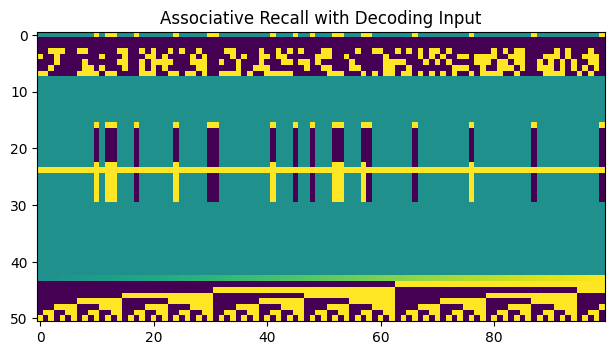

In [837]:
m = model.embedding(x) + model.pos_emb

plt.title("Associative Recall with Decoding Input")
plt.tight_layout()

plt.imshow(m.detach().numpy()[0].T)

plt.savefig("fig/decode_recall_input.pdf")

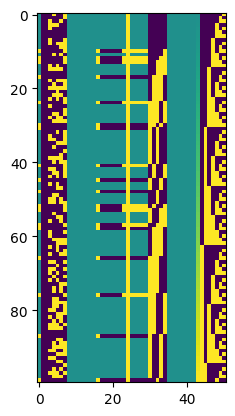

In [838]:
m = m + model.layers[0].layer(m)
# print("After")
plt.imshow(m.detach().numpy()[0])
print()

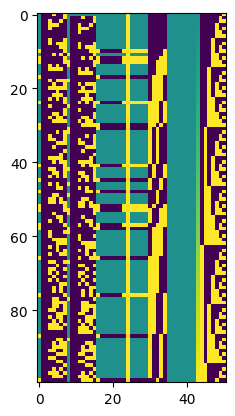

In [839]:
m = m + model.layers[1].layer(m)
plt.imshow(m.detach().numpy()[0])
print()

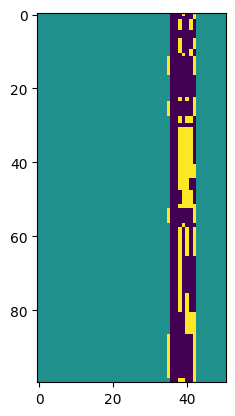

In [840]:
out, scores = model.layers[2].layer(m)
# plt.imshow((m+out).detach().numpy()[0])
plt.imshow((out).detach().numpy()[0])

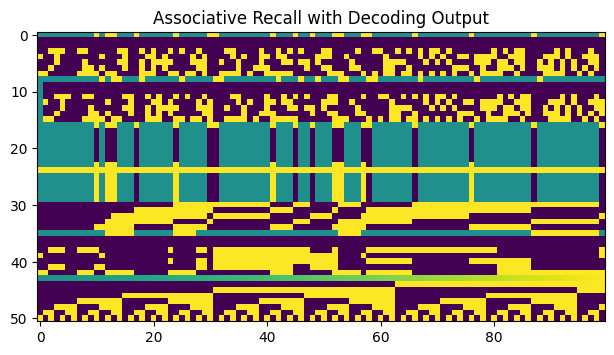

In [841]:
plt.title("Associative Recall with Decoding Output")
plt.tight_layout()

plt.imshow((m+out).detach().numpy()[0].T)

plt.savefig("fig/decode_recall_output.pdf")

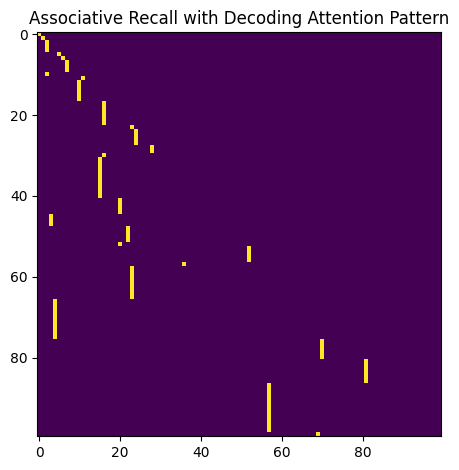

In [842]:
plt.title("Associative Recall with Decoding Attention Pattern")
plt.tight_layout()

plt.imshow(scores.detach().numpy()[0,0])

plt.savefig("fig/decode_recall_attention_pattern.pdf")

In [843]:
qkv = model.layers[2].layer.qkv(m)
q, k, v = qkv.chunk(3, dim=-1)

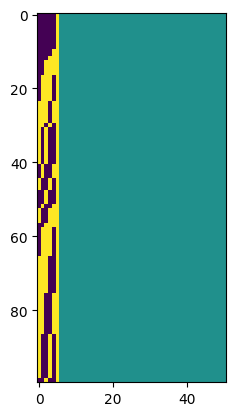

In [844]:
plt.imshow(q.detach().numpy()[0])

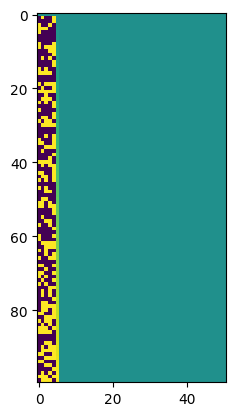

In [845]:
plt.imshow(k.detach().numpy()[0])

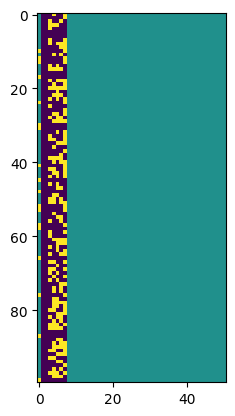

In [846]:
plt.imshow(v.detach().numpy()[0])

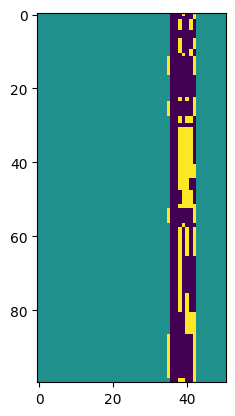

In [847]:
plt.imshow(out.detach().numpy()[0])

In [848]:
y

tensor([[36, 36, 36, 36, 36, 36,  0, 17, 17, 17, 18, 18, 33, 36, 36, 36, 36, 36,
         36, 36, 36, 36, 36, 21, 36, 36, 36, 36, 36, 36, 36, 30, 30, 30, 30, 30,
         30, 30, 30, 30, 30, 31, 31, 31, 31, 28, 28, 28, 14, 14, 14, 14, 31, 36,
         36, 36, 36,  8, 21, 21, 21, 21, 21, 21, 21, 21, 16, 16, 16, 16, 16, 16,
         16, 16, 16, 16, 20, 20, 20, 20, 20,  7,  7,  7,  7,  7,  7, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 25]])

In [849]:
(m+out)[0,-1, 3*l+2:4*l+2]

tensor([-1., -1., -1., -1., -1., -1.,  1., -1.], grad_fn=<SliceBackward0>)

In [850]:
y

tensor([[36, 36, 36, 36, 36, 36,  0, 17, 17, 17, 18, 18, 33, 36, 36, 36, 36, 36,
         36, 36, 36, 36, 36, 21, 36, 36, 36, 36, 36, 36, 36, 30, 30, 30, 30, 30,
         30, 30, 30, 30, 30, 31, 31, 31, 31, 28, 28, 28, 14, 14, 14, 14, 31, 36,
         36, 36, 36,  8, 21, 21, 21, 21, 21, 21, 21, 21, 16, 16, 16, 16, 16, 16,
         16, 16, 16, 16, 20, 20, 20, 20, 20,  7,  7,  7,  7,  7,  7, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 25]])